In [ ]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import numpy as np # for numerical analysis 
import seaborn as sns # visualizations
import matplotlib.pyplot as plt # aids in visualization 
import statsmodels.api as sm 

In [27]:
# Generate data using numpy 
np.random.seed(42) # reproducability
n = 200 # size of the data
score = np.random.uniform(1,10, n) # predictor
z = -1 + 0.8 * score  # y = mx +c => logit
prob = 1/ (1+ np.exp(-z)) # inverse of the logit
y = np.random.binomial(1, prob, n) # binary outcomes
df  = pd.DataFrame({'score':score, 'y':y}) # convert to data frame

In [10]:
df

,score,y
0,4.370861,1
1,9.556429,1
2,7.587945,1
3,6.387926,1
4,2.404168,1
...,...,...
195,4.142886,0
196,7.533601,1
197,9.073992,1
198,8.983778,1


In [ ]:
# instance of the model  &  fit its
X = sm.add_constant(df['score'])

model = sm.Logit(df['y'], X).fit() # training

Optimization terminated successfully.
         Current function value: 0.262104
         Iterations 8


In [ ]:
model.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.3378
Time:                        22:02:24   Log-Likelihood:                -52.421
converged:                       True   LL-Null:                       -79.156
Covariance Type:            nonrobust   LLR p-value:                 2.624e-13
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5662      0.580     -2.701      0.007      -2.703      -0.430
score          0.9452      0.198      4.780      0.000       0.558       1.333
==============================================================================
"""

In [ ]:
score_range = np.linspace(0,10, 200) # generating the test
X_pred = sm.add_constant(score_range)
pred_probs = model.predict(X_pred)

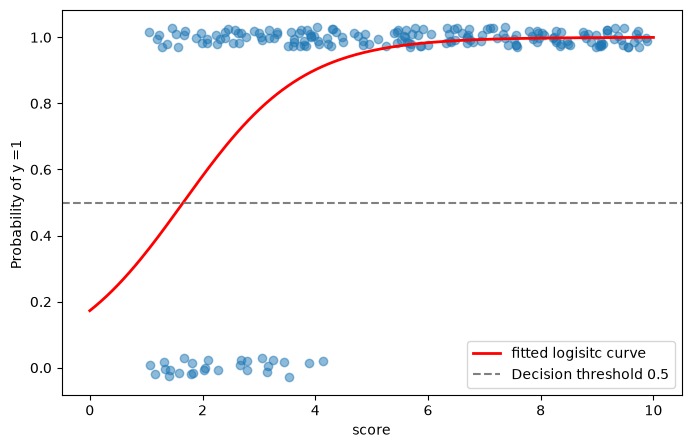

In [25]:
plt.figure(figsize=(8,5))  
plt.scatter(df['score'], df['y']+ np.random.uniform(-0.03, 0.03, n), alpha=0.5)
plt.plot(score_range, pred_probs, 'r-', lw=2, label="fitted logisitc curve")
plt.axhline(0.5, color="grey", linestyle='--', label='Decision threshold 0.5')
plt.xlabel('score')
plt.ylabel('Probability of y =1 ')
plt.legend()
plt.show()